In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("gurgaon_properties_cleaned_v1.csv")

In [4]:
df.duplicated().sum()

122

In [5]:
df.sample(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
3201,flat,dlf belvedere towers,sector 25,3.4,13765.0,2470.0,Carpet area: 2470 (229.47 sq.m.),4,4,3,servant room,1.0,South-East,10+ Year Old,"['Vodafone belvedere towers metro station', 'Dlf phase 3 metro station', 'Dlf phase 2 metro station', 'Indusind bank cyber city metro station', 'Micromax moulsari avenue metro station', 'Sikandarpur metro station', 'Sikanderpur metro station', 'Shri Shiv Shakthi Mandir', 'Central bank atm teste 001112', 'Central bank ATM', 'Kotak mahindra ATM', 'Citibank ATM', 'Abn amro bank ATM', 'RBS Dental Clinic', 'Kailash Nursing Home Gurgaon', 'Relief Physiotherapy Clinic', 'Darpan Skin & Mind Clinic', 'Cosmodentz Dental Clinic', 'Asha Multispeciality Clinic', 'Durga Poly Clinic', 'Krishna Family Clinic', 'Upkar Clinic', 'Surgi Center Clinic', 'R.N Clinic', 'Shri Ram Memorial Hospital', 'Dental Harbour', 'Uma Sanjeevani Health Centre And Hospital', 'Shri Balaji Medical Store', 'Guardian', 'DLF Cyber City Phase II', 'Emaar Business Park', 'SP Infocity', 'Standard chartered bank', 'Icici bank', 'Deutsche bank', 'Mc Donalds', 'Food Court', 'Mukesh Dhaba', 'The God Father', ""McDonald's"", 'barrique', 'Cantine', 'Machaan', 'American Montessori']",NaN,"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park']"


# 1 areaWithType

In [6]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
1802,2.65,3150.0,Super Built up area 3150(292.64 sq.m.)
2472,1.36,1538.0,Super Built up area 1538(142.88 sq.m.)
1745,1.20,1444.0,Super Built up area 1444(134.15 sq.m.)
3516,2.55,1950.0,Super Built up area 3150(292.64 sq.m.)Carpet area: 1950 sq.ft. (181.16 sq.m.)
854,2.28,2103.0,Super Built up area 2103(195.38 sq.m.)Built Up area: 1750 sq.ft. (162.58 sq.m.)Carpet area: 1257 sq.ft. (116.78 sq.m.)


In [7]:
# This function extracts the Super Bulit up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [9]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [10]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [11]:
df.duplicated().sum()

122

In [12]:
# displaying the row and columns of data where all three categories of areWithType has some value
df[~((df['super_built_up_area'].isnull()) | (df["built_up_area"].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [13]:
# here checking the NaN of those where areWithType is plot
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,7.5,house,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 sq.yards (201.51 sq.m.)Carpet area: 240 sq.yards (200.67 sq.m.),NaN,241.0,240.0
3,NaN,house,NaN,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
5,0.5,house,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 sq.ft. (67.35 sq.m.)Carpet area: 675 sq.ft. (62.71 sq.m.),NaN,725.0,675.0
7,5.0,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
13,9.0,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN


In [14]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [15]:
# Displaying the data of those rows where all three categories of areWithType has NaN value.
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [16]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,NaN,house,NaN,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
7,5.0,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
13,9.0,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
15,5.5,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
34,2.3,house,1352.0,Plot area 160(133.78 sq.m.),NaN,NaN,NaN


In [17]:
# we have a NaN here because areWithType has a category plotarea
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,NaN,house,NaN,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
7,5.0,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
13,9.0,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
15,5.5,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
34,2.3,house,1352.0,Plot area 160(133.78 sq.m.),NaN,NaN,NaN


In [18]:
# Here i am storing the index of those rows where all the three categories of areaWithType has NaN values (for future porpuse)
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [19]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [20]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [21]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1659,3.25,house,4000.0,Plot area 4000(371.61 sq.m.),NaN,4000.0,NaN
3131,7.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.0,NaN
2699,10.00,house,550.0,Plot area 550(51.1 sq.m.),NaN,550.0,NaN
2997,5.85,house,2214.0,Plot area 246(205.69 sq.m.),NaN,246.0,NaN
344,1.30,house,1152.0,Plot area 1152(107.02 sq.m.),NaN,1152.0,NaN


In [22]:
# here plot area are in sq_yard i have to convert it into sq_ft
# 1 sq_yard = 9 sq_ft
# plot_area * 9
# 240 *9


In [23]:
# to convert sq_mt into sq_ft
# 1 sq_yard = 10.7639 sq_ft
# plot_area * 10.7639 

In [24]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [25]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [26]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,NaN,house,NaN,Plot area 500(418.06 sq.m.),NaN,500.00,NaN
7,5.00,house,2367.0,Plot area 263(219.9 sq.m.),NaN,2367.00,NaN
13,9.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
15,5.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN
34,2.30,house,1352.0,Plot area 160(133.78 sq.m.),NaN,160.00,NaN
36,8.10,house,2295.0,Plot area 255(213.21 sq.m.),NaN,2295.00,NaN
53,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
55,1.64,house,1620.0,Plot area 180(150.5 sq.m.),NaN,1620.00,NaN
64,6.50,house,4320.0,Plot area 480(401.34 sq.m.),NaN,4320.00,NaN
65,3.60,house,1836.0,Plot area 204(170.57 sq.m.),NaN,1836.00,NaN


In [27]:
# update the original dataframe
df.update(all_nan_df)

In [28]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [29]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,the close north,sector 50,2.35,11767.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up area: 1950 sq.ft. (181.16 sq.m.)Carpet area: 1850 sq.ft. (171.87 sq.m.),3,3,3+,not available,8.0,North-East,5 to 10 Year Old,"['Sector 55-56 Metro Station', 'Eros City Square', 'Golf Course Ext Road', 'Badshapur Sohna Highway', 'Lotus Valley International School', 'Sushant University', 'Park Hospital', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station']","['5 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '15 Light', '1 Modular Kitchen', '1 Curtains', '5 AC', '1 Chimney', '4 Wardrobe', '1 Microwave', 'No Bed', 'No Dining Table', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",1997.0,1950.0,1850.0
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,"servant room,others",10.0,East,0 to 1 Year Old,"['Dwarka Sector 21 Metro Station', 'NeoSquare Mall', 'Dwarka Expressway', 'Euro International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Accenture DDC5', 'Hyatt Place Gurgaon Udyog Vihar', 'Hamoni Golf Camp', 'Nehru Stadium']",[],"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2585.0,NaN,NaN
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 sq.yards (201.51 sq.m.)Carpet area: 240 sq.yards (200.67 sq.m.),3,3,2,servant room,2.0,West,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Sri Radhe Krishna Temple', 'Standard chartered ATM', 'Icici bank ATM', 'Vatsalya Clinic', 'Bones Clinic - Orthopaedics', 'Skin Clinic', 'Divine Look Clinic Centre', 'Meher Clinic', 'Dr. Naresh Pandita', 'Dr. Anuj Sharma', 'Vishesh Dental', 'Neelkanth Health Care', 'Park Hospital Gurgaon', 'Dr. Aruna Kalra', 'Wellness Eye Centre', 'Best Urologist Atcomplete Family Clinic', 'Sanjeevani Hospital Gurgaon', 'Sai Heart and Trauma Center', 'Ekta Hospital', 'Sona Devi Memorial Hospital and Trauma Centre', 'Sai Dharamraj Hospital', 'Wembley estate club', 'Genius', 'Gardian Pharmacy', 'Apollo Pharmacy', 'SPAZE BUSINESS PARK', 'Unitech', 'Hdfc bank', 'Hdfc bank', 'Hdfc bank', 'Indusind bank', 'Icici bank', 'Central bank of india', 'SRS Cinemas', 'Madison and Pike', 'India', 'Haldiram', 'Starbucks', 'Nook', ""Domino's Pizza"", ""Nirula's"", 'Kamla International', 'Gurugram University', 'Delhi Public School Primary Section', 'Amity Global School']","['1 Exhaust Fan', '4 Geyser', '1 Stove', '1 Microwave', '18 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Fan', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'High Ceiling Height', 'Maintenance Staff', 'Separate entry for servant room', 'No open drainage around', 'Park', 'Visitor Parking', 'Natural Light', 'Airy Room

# 2 aditionalRoom

In [30]:
df["additionalRoom"].unique()

array(['not available', 'servant room,others', 'servant room',
       'pooja room,store room,study room,servant room', 'study room',
       'pooja room', 'servant room,store room', 'others',
       'pooja room,study room,servant room,others',
       'pooja room,study room,servant room,store room',
       'pooja room,study room,servant room',
       'servant room,study room,pooja room', 'store room',
       'study room,servant room', 'pooja room,servant room,others',
       'pooja room,store room', 'pooja room,servant room',
       'others,servant room', 'store room,pooja room,servant room',
       'study room,others', 'study room,pooja room',
       'pooja room,study room',
       'pooja room,study room,store room,servant room',
       'servant room,others,store room,pooja room',
       'store room,servant room',
       'study room,pooja room,servant room,store room',
       'servant room,pooja room',
       'servant room,study room,pooja room,store room',
       'pooja room,others', '

In [31]:
df["additionalRoom"].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [32]:
# in additional room we have a 6 unique categories.
# 1. not available
# 2. servent room
# 3. study room
# 4. others
# 5. pooja room
# 6. store room

In [33]:
# additional room
# List of new columns to be created
new_cols = ["study room", "servant room","store room","pooja room","others"]

# create a new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df["additionalRoom"].str.contains(col).astype(int)
    

In [34]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,the close north,sector 50,2.35,11767.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up area: 1950 sq.ft. (181.16 sq.m.)Carpet area: 1850 sq.ft. (171.87 sq.m.),3,3,3+,not available,8.0,North-East,5 to 10 Year Old,"['Sector 55-56 Metro Station', 'Eros City Square', 'Golf Course Ext Road', 'Badshapur Sohna Highway', 'Lotus Valley International School', 'Sushant University', 'Park Hospital', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station']","['5 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '15 Light', '1 Modular Kitchen', '1 Curtains', '5 AC', '1 Chimney', '4 Wardrobe', '1 Microwave', 'No Bed', 'No Dining Table', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",1997.0,1950.0,1850.0,0,0,0,0,0
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,"servant room,others",10.0,East,0 to 1 Year Old,"['Dwarka Sector 21 Metro Station', 'NeoSquare Mall', 'Dwarka Expressway', 'Euro International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Accenture DDC5', 'Hyatt Place Gurgaon Udyog Vihar', 'Hamoni Golf Camp', 'Nehru Stadium']",[],"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2585.0,NaN,NaN,0,1,0,0,1
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 sq.yards (201.51 sq.m.)Carpet area: 240 sq.yards (200.67 sq.m.),3,3,2,servant room,2.0,West,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Sri Radhe Krishna Temple', 'Standard chartered ATM', 'Icici bank ATM', 'Vatsalya Clinic', 'Bones Clinic - Orthopaedics', 'Skin Clinic', 'Divine Look Clinic Centre', 'Meher Clinic', 'Dr. Naresh Pandita', 'Dr. Anuj Sharma', 'Vishesh Dental', 'Neelkanth Health Care', 'Park Hospital Gurgaon', 'Dr. Aruna Kalra', 'Wellness Eye Centre', 'Best Urologist Atcomplete Family Clinic', 'Sanjeevani Hospital Gurgaon', 'Sai Heart and Trauma Center', 'Ekta Hospital', 'Sona Devi Memorial Hospital and Trauma Centre', 'Sai Dharamraj Hospital', 'Wembley estate club', 'Genius', 'Gardian Pharmacy', 'Apollo Pharmacy', 'SPAZE BUSINESS PARK', 'Unitech', 'Hdfc bank', 'Hdfc bank', 'Hdfc bank', 'Indusind bank', 'Icici bank', 'Central bank of india', 'SRS Cinemas', 'Madison and Pike', 'India', 'Haldiram', 'Starbucks', 'Nook', ""Domino's Pizza"", ""Nirula's"", 'Kamla International', 'Gurugram University', 'Delhi Public School Primary Section', 'Amity Global School']","['1 Exhaust Fan', '4 Geyser', '1 Stove', '1 Microwave', '18 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Fan', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'High Ceiling Height', 'Maintenance Staff', 'Separate entry for servant room', 'No open

# 3 agePossession

In [35]:
df["agePossession"].unique()

array(['5 to 10 Year Old', '0 to 1 Year Old', '1 to 5 Year Old', 'Jan-24',
       '10+ Year Old', 'undefined', 'Jan-26', 'Oct-24', 'Within 6 months',
       'By 2025', 'Under Construction', 'Mar-24', 'Within 3 months',
       'Dec-24', 'By 2023', 'Dec-23', 'Aug-26', 'Sep-23', 'Apr-26',
       'By 2024', 'May-24', 'Jun-27', 'Aug-23', 'Nov-24', nan, 'Mar-26',
       'Jun-24', 'Apr-24', 'Dec-25', 'Aug-25', 'Feb-24', 'Jan-25',
       'Nov-23', 'Jan-27', 'Oct-23', 'Aug-24', 'Sep-25', 'Dec-26',
       'Jul-25', 'Oct-25', 'Jul-24', 'By 2027', 'Jun-25', 'Jan-28',
       'Mar-25', 'Jul-27', 'Sep-27', 'Nov-25', 'Jul-26'], dtype=object)

In [36]:
df["agePossession"].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec-23                  22
By 2023                 19
By 2024                 17
Dec-24                  16
Mar-24                  14
Jan-24                   8
Oct-24                   8
Jun-24                   7
Dec-25                   7
Aug-23                   7
Nov-23                   5
Jul-24                   4
Sep-23                   4
Oct-23                   4
By 2025                  4
Aug-24                   4
May-24                   3
Nov-24                   3
Feb-24                   3
Jan-25                   3
Jul-25                   2
Oct-25                   2
Dec-26                   2
Sep-25                   2
By 2027                  2
Jun-27                   2
Jul-27                   2
Aug-25                   2
Apr-26        

In [37]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "Within 6 months" in value or "Within 3 months" in value or "0 to 1 Year Old" in value :
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately old"
    if "10+ Year Old" in value:
        return "Old Property"
    if  "Under Construction" in value or "By" in value:
        return "Under Construction"
    try: # for entire like May 2027
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [38]:
df["agePossession"] = df["agePossession"].apply(categorize_age_possession)

In [39]:
df["agePossession"].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately old         575
Undefined              484
Old Property           310
Under Construction     132
Name: count, dtype: int64

# 4.furnishDetails

In [40]:
df.sample(5)[["furnishDetails","features"]]

,furnishDetails,features
596,"['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '2 Geyser', '5 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Club house / Community Center', 'Rain Water Harvesting']"
1644,"['3 Wardrobe', '1 Water Purifier', '1 Fan', '1 Exhaust Fan', '4 Geyser', '1 Light', '1 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Security / Fire Alarm', 'Power Back-up', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
459,"['4 Wardrobe', '1 Water Purifier', '5 Fan', '1 Exhaust Fan', '6 Geyser', '1 Stove', '6 Light', '1 Modular Kitchen', '6 AC', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1037,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3010,"['3 Wardrobe', '2 Bed', '4 Fan', '1 Fridge', '1 Exhaust Fan', '3 Geyser', '21 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Recently Renovated', 'Swimming Pool', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"


In [41]:
df["furnishDetails"].unique()

array(["['5 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '15 Light', '1 Modular Kitchen', '1 Curtains', '5 AC', '1 Chimney', '4 Wardrobe', '1 Microwave', 'No Bed', 'No Dining Table', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",
       '[]',
       "['1 Exhaust Fan', '4 Geyser', '1 Stove', '1 Microwave', '18 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Fan', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",
       ...,
       "['7 Wardrobe', '9 Fan', '1 Exhaust Fan', '2 Geyser', '15 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",
       "['1 Geyser', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No S

In [42]:
df["furnishDetails"].value_counts()

furnishDetails
[]                                                                                                                                                                                                                                                                       421
['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']     199
['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']      72
['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fri

In [43]:
# Extract all unique furnishings from the furnishDetails column

In [44]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))



# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0



# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings



# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))



# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


In [45]:
furnishings_df.shape


(3803, 19)

In [46]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/var/folders/c0/tpr15gz15g3b80bhsy9dx2dc0000gn/T/ipykernel_22795/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [47]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [48]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [49]:
from sklearn.cluster import KMeans

wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

In [50]:
# wcss_reduced = []

# for i in range(1, 11):
#     kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
#     kmeans.fit(scaled_data)
#     wcss_reduced.append(kmeans.inertia_)

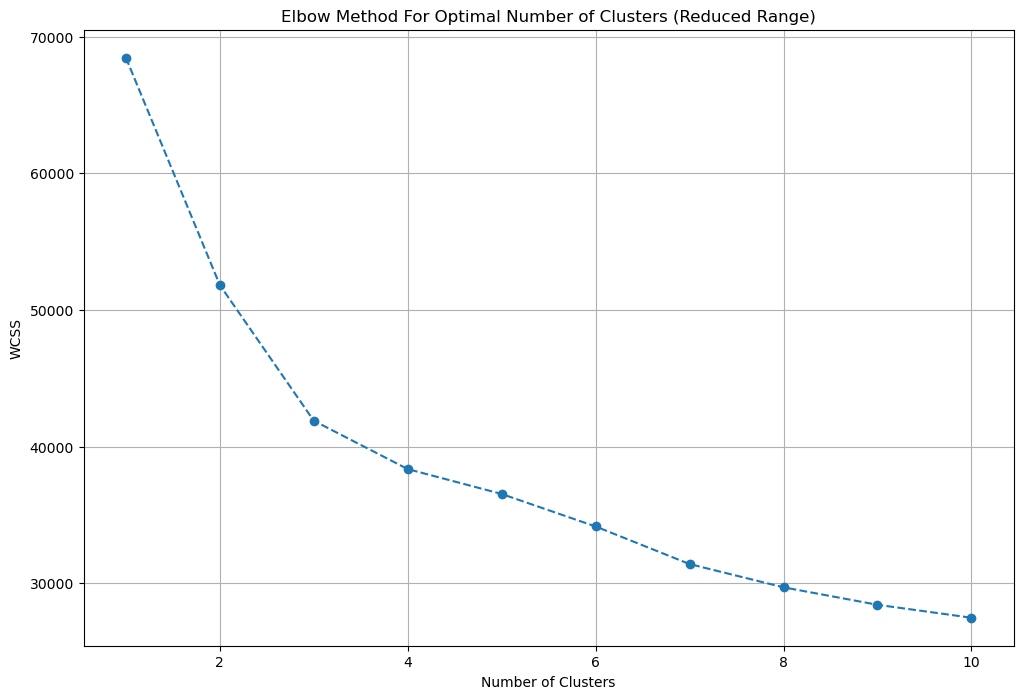

In [51]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [52]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [53]:
df = df.iloc[:,:-18]

In [54]:
df['furnishing_type'] = cluster_assignments

In [55]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
116,[],2
809,"['5 Fan', '1 Exhaust Fan', '1 Geyser', '8 Light', '1 AC', '1 TV', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '4 Bed', '1 Microwave', 'No Dining Table', 'No Fridge', 'No Sofa', 'No Stove', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
2320,"['7 Fan', '11 Light', '7 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
3442,"['2 Fan', '1 Fridge', '1 Geyser', '1 Stove', '4 Light', '1 Chimney', '1 Modular Kitchen', '2 AC', '2 TV', '1 Curtains', '1 Bed', '1 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Dining Table', 'No Exhaust Fan', 'No Water Purifier']",1
2155,"['4 Wardrobe', '8 Fan', '5 Geyser', '16 Light', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0


# features

In [57]:
df[['society','features']].sample(5)

,society,features
727,la vida by tata housing,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1582,bestech park view sanskruti,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
319,shree vardhman victoria,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
1312,emaar mgf emerald floors premier,"['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1267,bestech park view residency,"['Security / Fire Alarm', 'Power Back-up', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Recently Renovated', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"


In [58]:
df['features'].isnull().sum()

635

In [60]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [61]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [62]:
temp_df = df[df['features'].isnull()]